# Meta Motivo Tutorial
This notebook provides a simple introduction on how to use the Meta Motivo api.

## All imports

In [1]:
from packaging.version import Version
from metamotivo.fb_cpr.huggingface import FBcprModel
from huggingface_hub import hf_hub_download
from humenv import make_humenv
import gymnasium
from gymnasium.wrappers import FlattenObservation, TransformObservation
from metamotivo.buffers.buffers import DictBuffer
from humenv.env import make_from_name
from humenv import rewards as humenv_rewards
import mujoco

import torch
import mediapy as media
import math
import h5py
from pathlib import Path
import numpy as np

## Model download
The first step is to download the model. We show how to use HuggingFace hub for that.

In [2]:
model = FBcprModel.from_pretrained("facebook/metamotivo-S-1")
print(model)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/98.1M [00:00<?, ?B/s]

FBcprModel(
  (_backward_map): BackwardMap(
    (net): Sequential(
      (0): Linear(in_features=358, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): Tanh()
      (3): Linear(in_features=256, out_features=256, bias=True)
      (4): Norm()
    )
  )
  (_forward_map): ForwardMap(
    (embed_z): Sequential(
      (0): DenseParallel(in_features=614, out_features=1024, n_parallel=2, bias=True)
      (1): ParallelLayerNorm([1024], eps=1e-05, elementwise_affine=True)
      (2): Tanh()
      (3): DenseParallel(in_features=1024, out_features=512, n_parallel=2, bias=True)
      (4): ReLU()
    )
    (embed_sa): Sequential(
      (0): DenseParallel(in_features=427, out_features=1024, n_parallel=2, bias=True)
      (1): ParallelLayerNorm([1024], eps=1e-05, elementwise_affine=True)
      (2): Tanh()
      (3): DenseParallel(in_features=1024, out_features=512, n_parallel=2, bias=True)
      (4): ReLU()
    )
    (Fs): Sequential(
      (0): De

**Run a policy from Meta Motivo:**

Now that we saw how to load a pre-trained Meta Motivo policy, we can prompt it and execute actions with it. 

The first step is to sample a context embedding `z` that needs to be passed to the policy.

In [3]:
device = "cpu"

if Version("0.26") <= Version(gymnasium.__version__) < Version("1.0"):
    transform_obs_wrapper = lambda env: TransformObservation(
            env, lambda obs: torch.tensor(obs.reshape(1, -1), dtype=torch.float32, device=device)
        )
else:
    transform_obs_wrapper = lambda env: TransformObservation(
            env, lambda obs: torch.tensor(obs.reshape(1, -1), dtype=torch.float32, device=device), env.observation_space
        )

env, _ = make_humenv(
    num_envs=1,
    wrappers=[
        FlattenObservation,
        transform_obs_wrapper,
    ],
    state_init="Default",
)

model.to(device)
z = model.sample_z(1)
print(f"embedding size {z.shape}")
print(f"z norm: {torch.norm(z)}")
print(f"z norm / sqrt(d): {torch.norm(z) / math.sqrt(z.shape[-1])}")
observation, _ = env.reset()
frames = [env.render()]
for i in range(30):
    action = model.act(observation, z, mean=True)
    observation, reward, terminated, truncated, info = env.step(action.cpu().numpy().ravel())
    frames.append(env.render())

media.show_video(frames, fps=30)

embedding size torch.Size([1, 256])
z norm: 16.0
z norm / sqrt(d): 1.0


This browser does not support the video tag.


### Computing Q-functions

FB-CPR provides a way of directly computing the action-value function of any policy embedding `z` on any task embedding `z_r`. Then, the Q function of a policy $z$ is given by

$Q(s,a, z) = F(s,a,z) \cdot z_r$

The task embedding can be computed in the following way. Given a set of samples labeled with rewards $(s,a,s',r)$, the task embedding is given by: 

$z_r = \mathrm{normalised}(\sum_{i \in \mathrm{batch}} r_i B(s'_i))$.

In [4]:
def Qfunction(state, action, z_reward, z_policy):
    F = model.forward_map(obs=state, z=z_policy.repeat(state.shape[0],1), action=action) # num_parallel x num_samples x z_dim
    Q = F @ z_reward.ravel()
    return Q.mean(axis=0)

z_reward = model.sample_z(1)
z_policy = model.sample_z(1)
state = torch.rand((10, env.observation_space.shape[0]), device=model.cfg.device, dtype=torch.float32)
action = torch.rand((10, env.action_space.shape[0]), device=model.cfg.device, dtype=torch.float32)*2 - 1
Q = Qfunction(state, action, z_reward, z_policy)
print(Q)

tensor([-258.8261,  166.7798,  -89.5389,  122.2956,  246.5003,  -20.9729,
        -152.0665, -145.1379, -126.6191,  311.9363])


## Prompting the model

We have seen that we can condition the model via the context variable `z`. We can control the task to execute via _prompting_ (or _policy inference_).

### Reward prompts
The first version of inference we investigate is the reward prompting, i.e., given a set of reward label samples we can infer in a zero-shot way the near-optimal policy for solving such task.

First step, download the data for inference. We provide a buffer for inference of about 500k samples. This buffer has been generated by randomly subsampling the final replay buffer.

In [5]:
local_dir = "metamotivo-S-1-datasets"
dataset = "buffer.hdf5"
buffer_path = hf_hub_download(
        repo_id="facebook/metamotivo-S-1",
        filename=f"data/{dataset}",
        repo_type="model",
        local_dir=local_dir,
    )
print(buffer_path)

data/buffer.hdf5:   0%|          | 0.00/19.8G [00:00<?, ?B/s]

metamotivo-S-1-datasets/data/buffer.hdf5


Now that we have download the h5 file for inference, we can conveniently loaded it in a buffer.

In [6]:
hf = h5py.File(buffer_path, "r")
print(hf.keys())
data = {}
for k, v in hf.items():
    print(f"{k:20s}: {v.shape}")
    data[k] = v[:]
buffer = DictBuffer(capacity=data["qpos"].shape[0], device="cpu")
buffer.extend(data)
del data

<KeysViewHDF5 ['ep_0', 'ep_1', 'ep_10', 'ep_100', 'ep_1000', 'ep_10000', 'ep_10001', 'ep_10002', 'ep_10003', 'ep_10004', 'ep_10005', 'ep_10006', 'ep_10007', 'ep_10008', 'ep_10009', 'ep_1001', 'ep_10010', 'ep_10011', 'ep_10012', 'ep_10013', 'ep_10014', 'ep_10015', 'ep_10016', 'ep_10017', 'ep_10018', 'ep_10019', 'ep_1002', 'ep_10020', 'ep_10021', 'ep_10022', 'ep_10023', 'ep_10024', 'ep_10025', 'ep_10026', 'ep_10027', 'ep_10028', 'ep_10029', 'ep_1003', 'ep_10030', 'ep_10031', 'ep_10032', 'ep_10033', 'ep_10034', 'ep_10035', 'ep_10036', 'ep_10037', 'ep_10038', 'ep_10039', 'ep_1004', 'ep_10040', 'ep_10041', 'ep_10042', 'ep_10043', 'ep_10044', 'ep_10045', 'ep_10046', 'ep_10047', 'ep_10048', 'ep_10049', 'ep_1005', 'ep_10050', 'ep_10051', 'ep_10052', 'ep_10053', 'ep_10054', 'ep_10055', 'ep_10056', 'ep_10057', 'ep_10058', 'ep_10059', 'ep_1006', 'ep_10060', 'ep_10061', 'ep_10062', 'ep_10063', 'ep_10064', 'ep_10065', 'ep_10066', 'ep_10067', 'ep_10068', 'ep_10069', 'ep_1007', 'ep_10070', 'ep_10071'

AttributeError: 'Group' object has no attribute 'shape'

In [11]:
data = {}
for k, v in hf["ep_0"].items():
    print(f"{k:20s}: {v.shape}")
    data[k] = v[:]

action              : (400, 69)
observation         : (401, 358)
qpos                : (401, 76)
qvel                : (401, 75)
reward              : (400, 1)
terminated          : (400, 1)
truncated           : (400, 1)
z                   : (400, 256)


In [13]:
data["qvel"].shape[0]

401

In [9]:
buffer = DictBuffer(capacity=data["qpos"].shape[0], device="cpu")
batch = buffer.sample(3)
for k, v in batch.items():
    print(f"Key: {k}, Value: {v}")

KeyError: 'qpos'

In [7]:
batch = buffer.sample(5)
for k, v in batch.items():
    print(f"{k:20s}: {v.shape}")

action              : torch.Size([5, 69])
next_observation    : torch.Size([5, 358])
next_qpos           : torch.Size([5, 76])
next_qvel           : torch.Size([5, 75])
observation         : torch.Size([5, 358])
qpos                : torch.Size([5, 76])
qvel                : torch.Size([5, 75])


As you can see, the buffer does not provide a reward signal. We need to label this buffer with the desired reward function. We provide API for that but here we start looking into the basic steps:
* Instantiate a reward function
* Computing the reward from the batch data

In [8]:
reward_fn = humenv_rewards.LocomotionReward(move_speed=2.0) # move ahead with speed 2
# humenv provides also a name-base reward initialization. We could
# get the same reward function in this way
# reward_fn = make_from_name("move-ego-0-2") 
print(reward_fn)

LocomotionReward(move_speed=2.0, stand_height=1.4, move_angle=0, egocentric_target=True, low_height=0.6, stay_low=False)


In [17]:
mj_model = env.unwrapped.model

# for i in range(mj_model.nbody):
#     print(f"ID {i} name: {mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_BODY, i)}")

# for i in range(mj_model.njoint):
#     print(f"ID {i} name: {mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_JOINT, i)}")

for i in range(mj_model.nsensor):
    print(f"ID {i} name: {mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_SENSOR, i)}")


ID 0 name: sensor_Pelvis_framelinvel
ID 1 name: sensor_L_Hip_framelinvel
ID 2 name: sensor_L_Knee_framelinvel
ID 3 name: sensor_L_Ankle_framelinvel
ID 4 name: sensor_L_Toe_framelinvel
ID 5 name: sensor_R_Hip_framelinvel
ID 6 name: sensor_R_Knee_framelinvel
ID 7 name: sensor_R_Ankle_framelinvel
ID 8 name: sensor_R_Toe_framelinvel
ID 9 name: sensor_Torso_framelinvel
ID 10 name: sensor_Spine_framelinvel
ID 11 name: sensor_Chest_framelinvel
ID 12 name: sensor_Neck_framelinvel
ID 13 name: sensor_Head_framelinvel
ID 14 name: sensor_L_Thorax_framelinvel
ID 15 name: sensor_L_Shoulder_framelinvel
ID 16 name: sensor_L_Elbow_framelinvel
ID 17 name: sensor_L_Wrist_framelinvel
ID 18 name: sensor_L_Hand_framelinvel
ID 19 name: sensor_R_Thorax_framelinvel
ID 20 name: sensor_R_Shoulder_framelinvel
ID 21 name: sensor_R_Elbow_framelinvel
ID 22 name: sensor_R_Wrist_framelinvel
ID 23 name: sensor_R_Hand_framelinvel
ID 24 name: sensor_Pelvis_frameangvel
ID 25 name: sensor_L_Hip_frameangvel
ID 26 name: sens

We can call the method `__call__` to obtain a reward value from the physics state. This function receives a mujoco model, qpos, qvel and the action. See the humenv tutorial for more information.

In [9]:
N = 100_000
batch = buffer.sample(N)
rewards = []
for i in range(N):
    rewards.append(
        reward_fn(
            env.unwrapped.model,
            qpos=batch["next_qpos"][i],
            qvel=batch["next_qvel"][i],
            ctrl=batch["action"][i])
    )
rewards = np.stack(rewards).reshape(-1,1)
print(rewards.ravel())

[3.37696814e-03 2.91289016e-01 8.41295517e-05 ... 1.91421813e-01
 7.92277332e-02 3.58672822e-02]


**Note** that the reward functions implemented in humenv are functions of next state and action which means we need to use `next_qpos` and `next_qvel` that are the physical state of the system at the next state.

We provide a multi-thread version for faster relabeling, see `metamotivo.wrappers.humenvbench.relabel`.

In [ ]:
from metamotivo.wrappers.humenvbench import relabel
rewards = relabel(
    env,
    qpos=batch["next_qpos"],
    qvel=batch["next_qvel"],
    action=batch["action"],
    reward_fn=reward_fn, 
    max_workers=8
)
print(rewards.ravel())

In [19]:
?model.reward_inference

Signature:
model.reward_inference(
    next_obs: torch.Tensor,
    reward: torch.Tensor,
    weight: torch.Tensor | None = None,
) -> torch.Tensor
Docstring: <no docstring>
File:      ~/exact/.venv/lib/python3.10/site-packages/metamotivo/fb/model.py
Type:      method

We can now infer the context `z` for the selected task.

In [20]:
z = model.reward_inference(
    next_obs=batch["next_observation"],
    reward=torch.tensor(rewards, device=model.cfg.device, dtype=torch.float32)
)
print(z.shape)

observation, _ = env.reset()
frames = [env.render()]
for i in range(30):
    action = model.act(observation, z, mean=True)
    observation, reward, terminated, truncated, info = env.step(action.cpu().numpy().ravel())
    frames.append(env.render())

media.show_video(frames, fps=30)

torch.Size([1, 256])


This browser does not support the video tag.


Let's compute the **Q-function** for this policy.

In [11]:
z_reward = torch.sum(
    model.backward_map(obs=batch["next_observation"]) * torch.tensor(rewards, dtype=torch.float32, device=model.cfg.device),
    dim=0
)
z_reward = model.project_z(z_reward)
Q = Qfunction(batch["observation"], batch["action"], z_reward, z)
print(Q)

tensor([4512.6396, 4407.5400, 4246.1372,  ..., 4298.4810, 4426.8799,
        3982.3025])


# Goal and Tracking prompts
The model supports two other modalities, `goal` and `tracking`. These two modalities expose similar functions for context inference:
- `def goal_inference(self, next_obs: torch.Tensor) -> torch.Tensor`
- `def tracking_inference(self, next_obs: torch.Tensor) -> torch.Tensor`
  
We show an example on how to perform goal inference.

goal pose


""

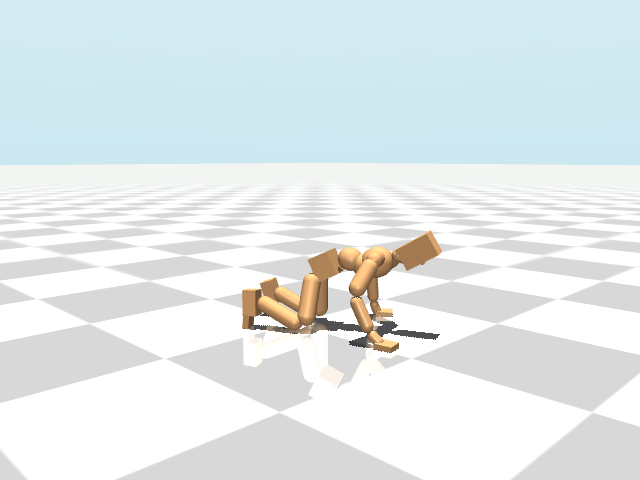

In [13]:
goal_qpos = np.array([0.13769039,-0.20029453,0.42305034,0.21707786,0.94573617,0.23868944
,0.03856998,-1.05566834,-0.12680767,0.11718296,1.89464102,-0.01371153
,-0.07981451,-0.70497424,-0.0478,-0.05700732,-0.05363342,-0.0657329
,0.08163511,-1.06263979,0.09788937,-0.22008936,1.85898192,0.08773695
,0.06200327,-0.3802791,0.07829525,0.06707749,0.14137152,0.08834448
,-0.07649805,0.78328658,0.12580912,-0.01076061,-0.35937259,-0.13176489
,0.07497022,-0.2331914,-0.11682692,0.04782308,-0.13571422,0.22827948
,-0.23456622,-0.12406075,-0.04466465,0.2311667,-0.12232673,-0.25614032
,-0.36237662,0.11197906,-0.08259534,-0.634934,-0.30822742,-0.93798716
,0.08848668,0.4083417,-0.30910404,0.40950143,0.30815359,0.03266103
,1.03959336,-0.19865537,0.25149713,0.3277561,0.16943092,0.69125975
,0.21721349,-0.30871948,0.88890484,-0.08884043,0.38474549,0.30884107
,-0.40933304,0.30889523,-0.29562966,-0.6271498])
env.unwrapped.set_physics(qpos=goal_qpos, qvel=np.zeros(75))
goal_obs = torch.tensor(env.unwrapped.get_obs()["proprio"].reshape(1,-1), device=model.cfg.device, dtype=torch.float32)
print("goal pose")
media.show_image(env.render())

In [14]:
z = model.goal_inference(next_obs=goal_obs)


observation, _ = env.reset()
frames = [env.render()]
for i in range(30):
    action = model.act(observation, z, mean=True)
    observation, reward, terminated, truncated, info = env.step(action.cpu().numpy().ravel())
    frames.append(env.render())

media.show_video(frames, fps=30)

This browser does not support the video tag.
